# 3Di alignment benchmark

## Description

We compare the performance of ESM3Di, compared to ProstT5, on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* `AF3`: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* `ProstT5`: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* `ESM3Di`: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database, run Foldseek `structurealign` module with 1-vs-1 basis (aligning identical entries).

The results are represented as the bitscore of the alignment, and 3Di sequence identity, which can be calculated as: 
$\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}$

---

## Database preparation

### Download and process the MetaVR dataset

In [1]:
from pathlib import Path
import os

DATAPATH = Path("/mnt/data1/metavir_structs").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /mnt/data1/metavir_structs


In [2]:
%%bash
# Download MetaVR dataset
mkdir -p "$DATAPATH/metavr"
#wget -q -O "$DATAPATH/metavr/IMGVR5_PC_3Dmodels.tar.gz" "https://www.meta-virome.org/Data/Downloads/IMGVR5_PC_3Dmodels.tar.gz"
tar -xzf "$DATAPATH/metavr/IMGVR5_PC_3Dmodels.tar.gz" -C "$DATAPATH/metavr"

# Create Foldseek database
mkdir -p "$DATAPATH/foldseek"


In [4]:
%%bash
mkdir -p "$DATAPATH/foldseek"

foldseek createdb "$DATAPATH/metavr/metaVR_structures_all" "$DATAPATH/foldseek/metavr_af3"

/mnt/data1/metavir_structs/foldseek/metavr_af3 exists and will be overwritten
createdb /mnt/data1/metavir_structs/metavr/metaVR_structures_all /mnt/data1/metavir_structs/foldseek/metavr_af3 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Output file: /mnt/data1/metavir_structs/foldseek/metavr_af3
[=================================================================] 748.93K 1h 24m 13s 800ms
Time for merging to metavr_af3_ss: 0h 0m 8s 56ms
Time for merging to metavr_af3_h: 0h 0m 1s 424ms
Time for merging to metavr_af3_ca: 0h 0m 4s 850ms
Time for merging to metavr_af3

### Predict 3Di representations with ProstT5

#### Generate AA FASTA file from the MetaVR dataset

In [7]:
%%bash
awk '{gsub(/\x00/, "", $0)} NR==FNR{f[FNR]=$0; next} f[FNR]{print ">"f[FNR]"\n"$0}' \
    "$DATAPATH/foldseek/metavr_af3_h" \
    "$DATAPATH/foldseek/metavr_af3" \
    > "$DATAPATH/metavr/metavr_aa.fa"

#### Predict 3Di with ProstT5

In [12]:
%%bash
#foldseek databases ProstT5 "$DATAPATH/prostt5_weights" "$DATAPATH/tmp"
rm -rf "$DATAPATH/tmp"
foldseek createdb "$DATAPATH/metavr/metavr_aa.fa" "$DATAPATH/foldseek/metavr_prostt5" --gpu 1 --prostt5-model "$DATAPATH/prostt5_weights"

/mnt/data1/metavir_structs/foldseek/metavr_prostt5 exists and will be overwritten
/mnt/data1/metavir_structs/foldseek/metavr_prostt5 exists and will be overwritten
createdb /mnt/data1/metavir_structs/metavr/metavr_aa.fa /mnt/data1/metavir_structs/foldseek/metavr_prostt5 --gpu 1 --prostt5-model /mnt/data1/metavir_structs/prostt5_weights 

MMseqs Version:             	10.941cd33
Use GPU                     	1
Path to ProstT5             	/mnt/data1/metavir_structs/prostt5_weights
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Converting sequences
[=====

Time for merging to metavr_prostt5_h: 0h 0m 0s 76ms
Time for merging to metavr_prostt5: 0h 0m 0s 214ms
Database type: Aminoacid


bash: line 3: 666894 Segmentation fault      (core dumped) foldseek createdb "$DATAPATH/metavr/metavr_aa.fa" "$DATAPATH/foldseek/metavr_prostt5" --gpu 1 --prostt5-model "$DATAPATH/prostt5_weights"


CalledProcessError: Command 'b'#foldseek databases ProstT5 "$DATAPATH/prostt5_weights" "$DATAPATH/tmp"\nrm -rf "$DATAPATH/tmp"\nfoldseek createdb "$DATAPATH/metavr/metavr_aa.fa" "$DATAPATH/foldseek/metavr_prostt5" --gpu 1 --prostt5-model "$DATAPATH/prostt5_weights"\n'' returned non-zero exit status 139.

### Predict 3Di representations with ESM3Di

In [3]:
%%bash
# Predict 3Di with ESM3Di and build the Foldseek database.
# Update MODEL_CKPT to the checkpoint you want to use.
MODEL_CKPT="./checkpoints_prostt5_bfvd_plddt_aux/model_epoch_30.pt"

python -m esm3di.fastas2foldseekdb \
    --aa-fasta "$DATAPATH/metavr/metavr_aa.fa" \
    --model-ckpt "$MODEL_CKPT" \
    --output-db "$DATAPATH/foldseek/metavr_esm3di" \
    --keep-fastas

usage: fastas2foldseekdb.py [-h] --aa-fasta AA_FASTA
                            [--three-di-fasta THREE_DI_FASTA]
                            [--model-ckpt MODEL_CKPT] [--skip-inference]
                            [--device DEVICE] [--num-gpus NUM_GPUS]
                            --output-db OUTPUT_DB [--keep-fastas]
                            [--output-aa-fasta OUTPUT_AA_FASTA]
                            [--output-3di-fasta OUTPUT_3DI_FASTA]
                            [--output-confidence-fasta OUTPUT_CONFIDENCE_FASTA]
                            [--foldseek-bin FOLDSEEK_BIN]
fastas2foldseekdb.py: error: Model checkpoint not found: ./checkpoints_prostt5_bfvd_plddt_aux/model_epoch_30.pt


CalledProcessError: Command 'b'# Predict 3Di with ESM3Di and build the Foldseek database.\n# Update MODEL_CKPT to the checkpoint you want to use.\nMODEL_CKPT="./checkpoints_prostt5_bfvd_plddt_aux/model_epoch_30.pt"\n\npython -m esm3di.fastas2foldseekdb \\\n    --aa-fasta "$DATAPATH/metavr/metavr_aa.fa" \\\n    --model-ckpt "$MODEL_CKPT" \\\n    --output-db "$DATAPATH/foldseek/metavr_esm3di" \\\n    --keep-fastas\n'' returned non-zero exit status 2.

---

## Run Foldseek structure alignment

Now we have 3 Foldseek databases for the MetaVR dataset in `$DATAPATH/foldseek`:
 * `metavr_af3`: 3Di generated by Foldseek
 * `metavr_prostt5`: 3Di generated by ProstT5
 * `metavr_esm3di`: 3Di generated by ESM3Di

### Alignment (AF3 vs. ProstT5)

#### Generate fake prefilter database for 1-vs-1 alignment

In [ ]:
%%bash
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
    "$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_prostt5_h" \
    > "$DATAPATH/metavr/metavr_prostt5_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_prostt5_pref.tsv" "$DATAPATH/foldseek/metavr_prostt5_pref" --output-dbtype 7

#### Run Foldseek alignment

In [ ]:
%%bash
foldseek structurealign -e INF \
    "$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
    "$DATAPATH/foldseek/metavr_prostt5_pref" "$DATAPATH/foldseek/metavr_prostt5_aln"

foldseek convertalis \
    "$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
    "$DATAPATH/foldseek/metavr_prostt5_aln" "$DATAPATH/metavr/metavr_prostt5_aln.tsv"

### Alignment (AF3 vs. ESM3Di)

In [ ]:
%%bash
# Generate prefilter database
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
    "$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_esm3di_h" \
    > "$DATAPATH/metavr/metavr_esm3di_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_esm3di_pref.tsv" "$DATAPATH/foldseek/metavr_esm3di_pref" --output-dbtype 7

# Run Foldseek alignment
foldseek structurealign -e INF \
    "$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
    "$DATAPATH/foldseek/metavr_esm3di_pref" "$DATAPATH/foldseek/metavr_esm3di_aln"

foldseek convertalis \
    "$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
    "$DATAPATH/foldseek/metavr_esm3di_aln" "$DATAPATH/metavr/metavr_esm3di_aln.tsv"

---

## Comparison of alignment scores

### Parse bitscores

In [ ]:
%%bash
paste \
    <(cut -f1,12 "$DATAPATH/metavr/metavr_prostt5_aln.tsv" | sort) \
    <(cut -f1,12 "$DATAPATH/metavr/metavr_esm3di_aln.tsv" | sort | cut -f2) \
    > "$DATAPATH/metavr/metavr_bitscores.tsv"

### Plot scores as a scatter plot

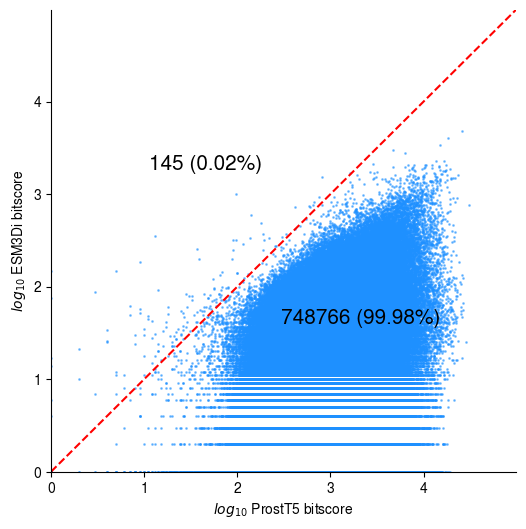

In [ ]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_bitscores.tsv") as f:
    for line in f:
        _, prostt5_score, esm3di_score = line.strip().split()
        x.append(int(prostt5_score))
        y.append(int(esm3di_score))

# take log
from math import log10
x = [0 if score <= 0 else log10(score) for score in x]
y = [0 if score <= 0 else log10(score) for score in y]

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# scatter plot
plt.scatter(x, y, alpha=0.5, s=1, color='dodgerblue')
plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/3, 2/3, txt_above, transform=ax.transAxes,
        ha="center", va="center", fontsize=15)
ax.text(2/3, 1/3, txt_below, transform=ax.transAxes,
        ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('$log_{10}$ ProstT5 bitscore')
plt.ylabel('$log_{10}$ ESM3Di bitscore')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

---

## Identity calculation

### Generate 3Di FASTA files for each representation

In [ ]:
%%bash
# AF3
foldseek base:lndb "$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_af3_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_af3_ss" "$DATAPATH/metavr/metavr_af3_3di.fa"

# ProstT5
foldseek base:lndb "$DATAPATH/foldseek/metavr_prostt5_h" "$DATAPATH/foldseek/metavr_prostt5_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_prostt5_ss" "$DATAPATH/metavr/metavr_prostt5_3di.fa"

# ESM3Di
foldseek base:lndb "$DATAPATH/foldseek/metavr_esm3di_h" "$DATAPATH/foldseek/metavr_esm3di_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_esm3di_ss" "$DATAPATH/metavr/metavr_esm3di_3di.fa"

### Generate combined TSV file

In [ ]:
%%bash
# Generate a TSV file with the following columns:
# [MetaVR ID], [AF3 3Di], [ProstT5 3Di], [ESM3Di 3Di]
paste \
    <(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_af3_3di.fa") \
    <(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_prostt5_3di.fa" | sort | cut -f2) \
    <(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_esm3di_3di.fa" | sort | cut -f2) \
    > "$DATAPATH/metavr/metavr_3di_comp.tsv"

# Ensure everything has equal length
awk 'length($2) != length($3) || length($2) != length($4) {print "Sanity check: ERROR"} END{print "Sanity check: OK"}' \
    "$DATAPATH/metavr/metavr_3di_comp.tsv"

### Calculate 3Di identity

In [ ]:
from pathlib import Path
import os

datapath = Path(os.environ["DATAPATH"])
outfile = open(datapath / "metavr/metavr_3di_identity.tsv", 'w')
with open(datapath / "metavr/metavr_3di_comp.tsv") as f:
    for line in f:
        metaVR_id, af3_3di, prostt5_3di, esm3di_3di = line.strip().split('\t')
        metaVR_id = metaVR_id[1:]  # remove '>' from FASTA header

        prostt5_identity = sum(a == b for a, b in zip(af3_3di, prostt5_3di)) / len(af3_3di) * 100
        esm3di_identity = sum(a == b for a, b in zip(af3_3di, esm3di_3di)) / len(af3_3di) * 100

        print(f'{metaVR_id}\t{prostt5_identity:.4f}\t{esm3di_identity:.4f}', file=outfile)
        x.append(prostt5_identity)
        y.append(esm3di_identity)

### Plot identity comparison as a density plot

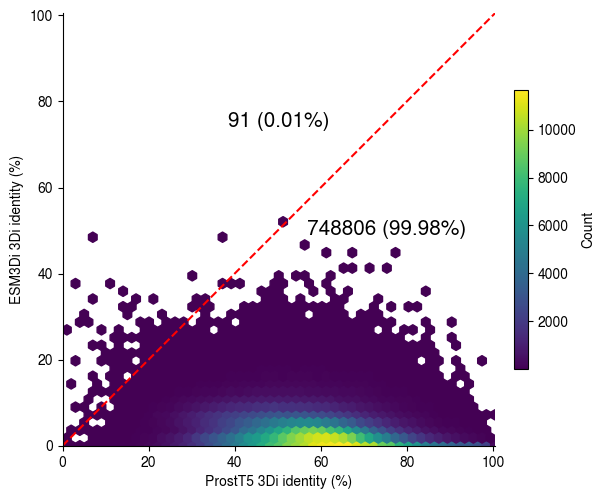

In [ ]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_3di_identity.tsv") as f:
    for line in f:
        _, prostt5_identity, esm3di_identity = line.strip().split('\t')
        x.append(float(prostt5_identity))
        y.append(float(esm3di_identity))

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# density plot with viridis colormap
ax.set_aspect("equal", adjustable="box")   
hb = ax.hexbin(
    x, y,
    gridsize=50,
    extent=(0, lim, 0, lim),
    cmap="viridis",
    mincnt=1,
    #linewidths=0.0,
 )
hb.set_alpha(1)

# add colormap legend indicating the count of points in each hexbin
# make it much smaller
plt.colorbar(hb, ax=ax, label='Count', fraction=0.03, pad=0.04)

plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/2, 3/4, txt_above, transform=ax.transAxes,
        ha="center", va="center", fontsize=15)
ax.text(3/4, 1/2, txt_below, transform=ax.transAxes,
        ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('ProstT5 3Di identity (%)')
plt.ylabel('ESM3Di 3Di identity (%)')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()